In [1]:
import numpy as np
import matplotlib.pyplot as plt
from magnonics import *
from configs_slab.truncated_trihexagonal_slabs import *

In [2]:
hamil, lat, basis = Initialize.from_csv('configs/truncated_trihexagonal.csv')

hamil.HP_trafo(symbolic=True)

hamil.parameterize_hamil(1e-8)

1e-08

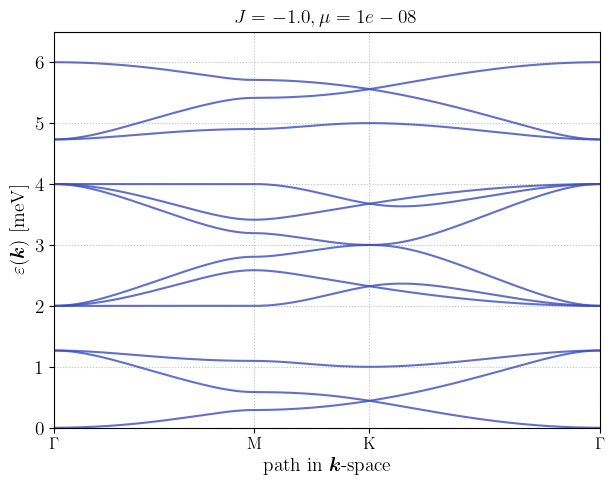

In [3]:
bz = Hexagonal(hamil, 'truncated_trihexagonal')
hsp = bz.hsp
disp = bz.get_dispersion(hsp.g, hsp.m, hsp.k, hsp.g, num = 200)
fig = bz.plot_bandstructure(disp, show_params=True, show_chern=False)
bz.save_plot(fig, overwrite=True)

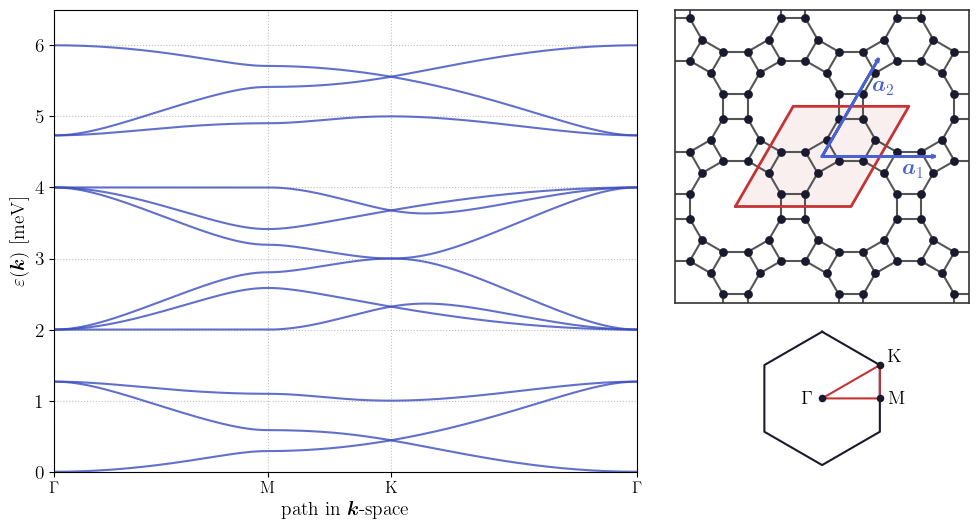

In [4]:
from numpy import sqrt

a = 1

a1 = ((sqrt(3)+3)*a, 0)
a2 = ((sqrt(3)+3)/2*a, 1.5*(sqrt(3)+1)*a)

base_pos = [
    (0.33333333, 0.12200847),
    (0.5446582, 0.12200847),
    (0.5446582, 0.33333333),
    (0.33333333, 0.5446582),
    (0.12200847, 0.5446582),
    (0.12200847, 0.33333333),
    (0.66666667, 0.4553418),
    (0.87799153, 0.4553418),
    (0.87799153, 0.66666667),
    (0.66666667, 0.87799153),
    (0.4553418, 0.87799153),
    (0.4553418, 0.66666667),
]

both = bz.plot_bs_and_lat(disp, 
                          a1, a2, base_pos, 
                          BZ_type='hexagonal',
                          n_shells=3,
                          view_size=6,
                          vect_label_offset_a1 = (-1, -0.5),
                          vect_label_offset_a2 = (0.1, -1.2),
                          figsize = (12,6),
                          wratio = [1.8, 1],
                          hratio = [2, 1],
                          wspace = 0.05,
                          hspace = 0.1,)

bz.save_plot(both, overwrite=True, filename='truncated_trihexagonal_BS_combined')

In [8]:
Da = -0.2
Db = -0.2
Dc = Db - Da

hamil.update_parameters({'Dz1': Da, 'Dz2': Db, 'Dz3': Dc}, 1e-8)

Updated parameters and now using 1e-08 as chemical potential.


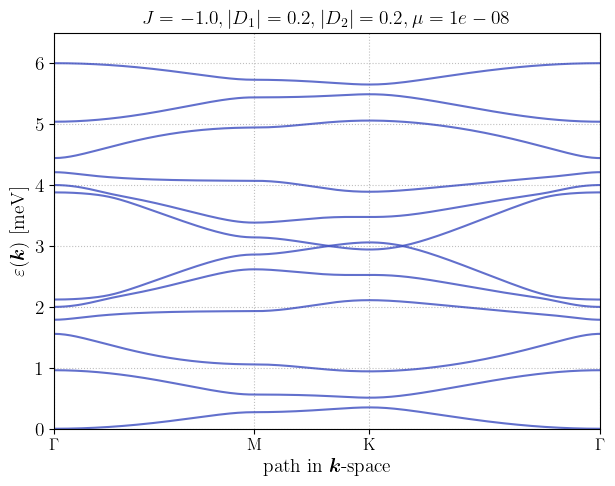

In [9]:
bz = Hexagonal(hamil, 'truncated_trihexagonal')
hsp = bz.hsp
disp = bz.get_dispersion(hsp.g, hsp.m, hsp.k, hsp.g, num = 200)
fig = bz.plot_bandstructure(disp, show_params=True, show_chern=False)
bz.save_plot(fig, overwrite=True)

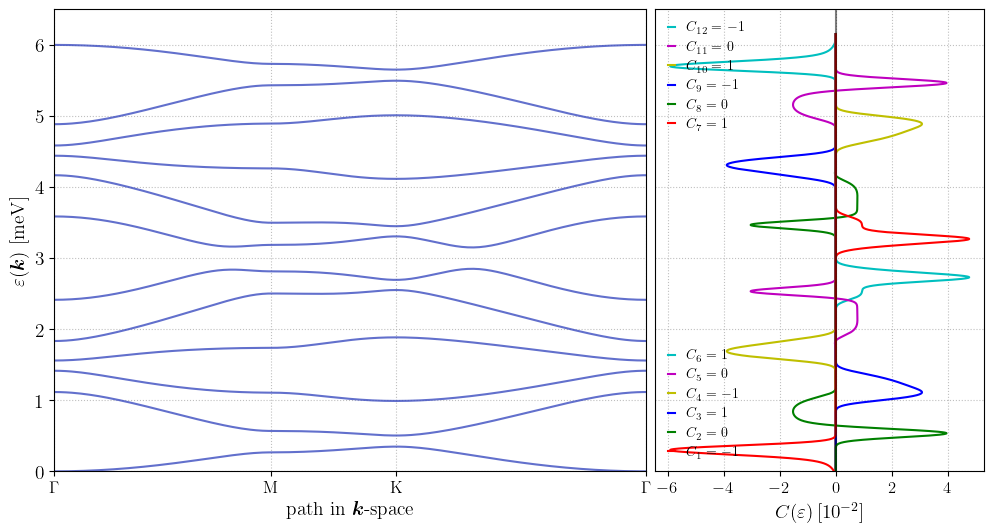

In [8]:
chern = bz.plot_bs_and_chern(disp,
                             chern_gridsize = 50,
                             sigma = 0.05,
                             points = 5000,
                             figsize = (12,6),
                             wratio = [1.8, 1],
                             wspace = 0.02,
                             show_chern = False,
                             split = True,
                             loc='upper left',
                             loc2='lower left')

bz.save_plot(chern, overwrite=True, filename='truncated_trihexagonal_chern_1')

In [13]:
Da = -0.3
Db = -0.3
Dc = Db - Da

hamil.update_parameters({'Dz1': Da, 'Dz2': Db, 'Dz3': Dc}, 1e-8)

Updated parameters and now using 1e-08 as chemical potential.


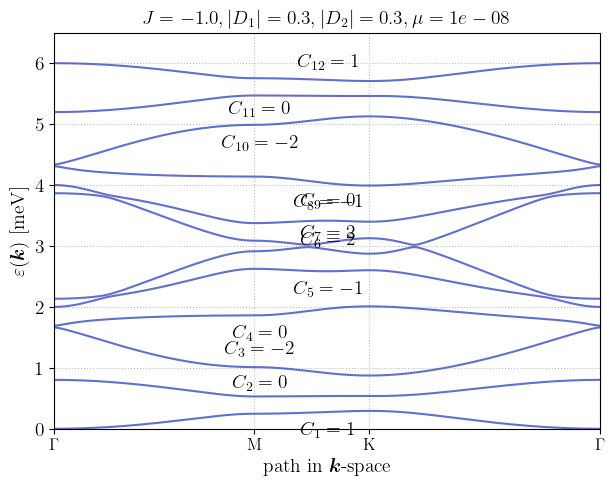

In [14]:
bz = Hexagonal(hamil, 'truncated_trihexagonal')
hsp = bz.hsp
disp = bz.get_dispersion(hsp.g, hsp.m, hsp.k, hsp.g, num = 200)
fig = bz.plot_bandstructure(disp, show_params=True, show_chern=True)
bz.save_plot(fig, overwrite=True)

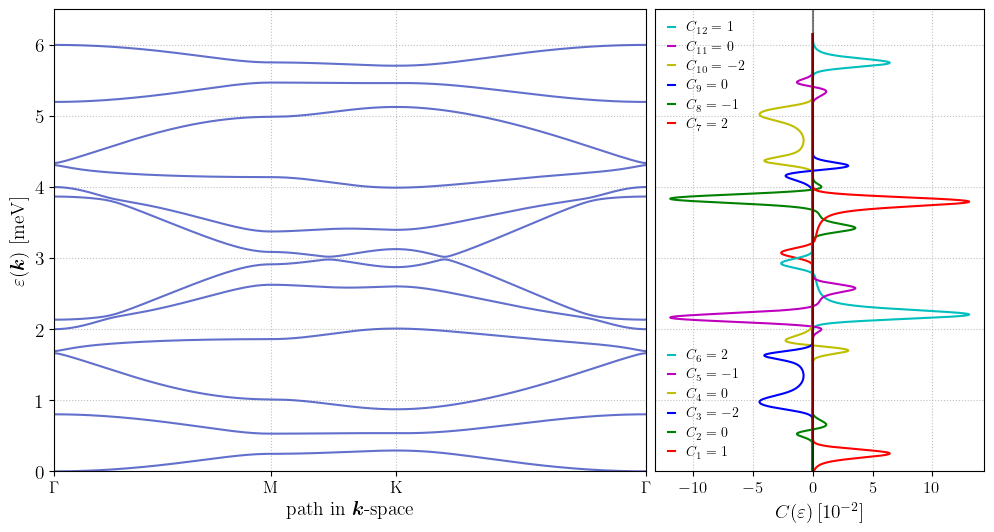

In [15]:
chern = bz.plot_bs_and_chern(disp,
                             chern_gridsize = 50,
                             sigma = 0.05,
                             points = 5000,
                             figsize = (12,6),
                             wratio = [1.8, 1],
                             wspace = 0.02,
                             show_chern=False,
                             split = True,
                             loc='upper left',
                             loc2='lower left')

bz.save_plot(chern, overwrite=True, filename='truncated_trihexagonal_chern_2')

In [20]:
Da = 0.2
Db = -0.2
Dc = Db - Da

hamil.update_parameters({'Dz1': Da, 'Dz2': Db, 'Dz3': Dc}, 1e-8)

Updated parameters and now using 1e-08 as chemical potential.


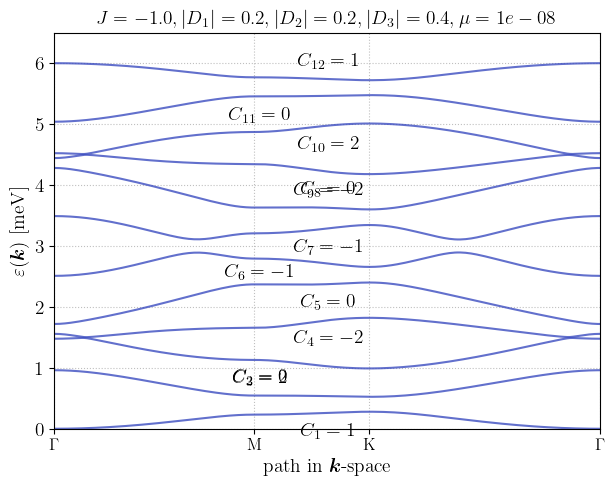

In [21]:
bz = Hexagonal(hamil, 'truncated_trihexagonal')
hsp = bz.hsp
disp = bz.get_dispersion(hsp.g, hsp.m, hsp.k, hsp.g, num = 200)
fig = bz.plot_bandstructure(disp, show_params=True, show_chern=True)
bz.save_plot(fig, overwrite=True)

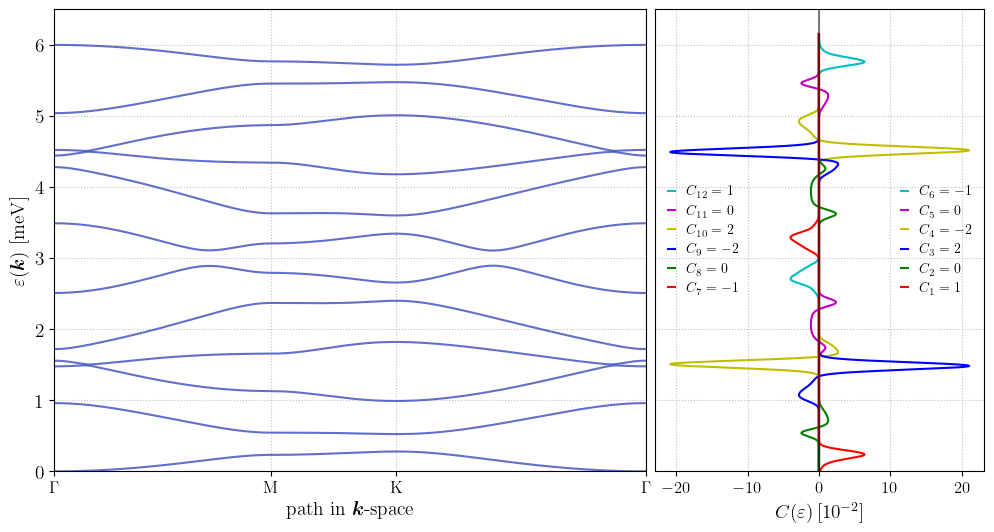

In [24]:
chern = bz.plot_bs_and_chern(disp,
                             chern_gridsize = 50,
                             sigma = 0.05,
                             points = 5000,
                             figsize = (12,6),
                             wratio = [1.8, 1],
                             wspace = 0.02,
                             show_chern=False,
                             split = True,
                             loc='center left',
                             loc2='center right')

bz.save_plot(chern, overwrite=True, filename='truncated_trihexagonal_chern_3')

In [23]:
Es, EVs = hamil.evgrid(40)

hamil.chern(EVs)

chern_numbers = np.around(hamil.chern(EVs), 2)

print(chern_numbers[:len(chern_numbers) // 2])
print(np.sum(chern_numbers[:len(chern_numbers) // 2],0))

[ 1. -0.  2. -2. -0. -1. -1. -0. -2.  2. -0.  1.]
0.0


Processing 12 bands with mixed shapes...


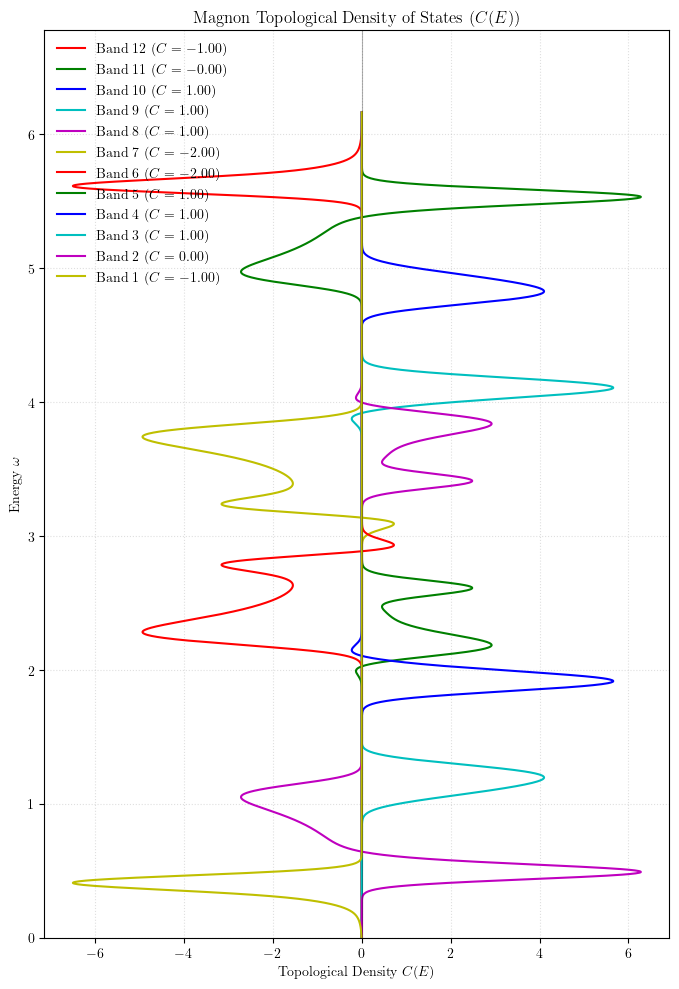

In [9]:
# params
sigma = 0.05
n_points = 5000
F_12 = - hamil.curvature_grid(EVs)

n_bands = F_12.shape[0]  # Get number of bands from the leading dim of F_12
    
# 1. Setup Energy Axis
e_min, e_max = np.min(Es) - 3*sigma, np.max(Es) + 3*sigma
energy_axis = np.linspace(e_min, e_max, n_points)

chern_density = np.zeros((n_points, n_bands))

print(f"Processing {n_bands // 2} bands with mixed shapes...")
for b in range(n_bands // 2):
    # F_12 is (Nbands, Nk1-1, Nk2-1) -> e.g., (N, 9, 9)
    # E is (Nk1, Nk2, Nbands) -> e.g., (10, 10, N)
    
    # 1. Match the shapes
    # We take the energy of the bottom-left corner of each plaquette
    nk1_flux, nk2_flux = F_12.shape[1], F_12.shape[2]
    
    energies_b = Es[:nk1_flux, :nk2_flux, b].ravel() # Slice E to (9, 9)
    flux_b = F_12[b].ravel()                        # Already (9, 9)
    
    # Now both are length 81
    diff = energy_axis[:, np.newaxis] - energies_b[np.newaxis, :]
    weights = (1.0 / (np.sqrt(2 * np.pi) * sigma)) * np.exp(-0.5 * (diff / sigma)**2)
    
    chern_density[:, b] = (weights @ flux_b) / (2 * np.pi)

# 4. Visualization
plt.figure(figsize=(7, 10))
total_density = np.sum(chern_density, axis=1)

colors = ['r', 'g', 'b', 'c', 'm', 'y', 'r', 'g', 'b', 'c', 'm', 'y']

for b in range(n_bands//2):
    c_val = np.sum(F_12[b]) / (2 * np.pi)
    plt.plot(chern_density[:, b], energy_axis, 
                label=f'Band {n_bands // 2 - b} ($C={c_val:.2f}$)', color=colors[b])

# plt.plot(total_density, energy_axis, 'k--', alpha=0.5, label='Total Sum')

plt.axvline(0, color='black', lw=0.8, alpha=0.3)
plt.xlabel(r"Topological Density $C(E)$")
plt.ylabel(r"Energy $\omega$")
plt.title(r"Magnon Topological Density of States ($C(E)$)")
plt.legend(frameon=False)
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.ylim(ymin=0)
plt.show()

In [2]:
width1 = 20
zigzag_zigzag = build_zigzag_zigzag(width1)

Setup file saved to: c:\Users\Pascal\Desktop\magnon_code\archimedean\configs_slab\truncated_trihexagonal_zigzag_zigzag.csv


In [3]:
zigzag_zigzag, _, _ = Initialize.from_csv('configs_slab/truncated_trihexagonal_zigzag_zigzag.csv')

zigzag_zigzag.HP_trafo(symbolic=True) ;

In [4]:
zigzag_zigzag.update_parameters({'Dz1': -0.3, 'Dz2': -0.3, 'Dz3': 0}, 1e-1)

Updated parameters and now using 0.1 as chemical potential.


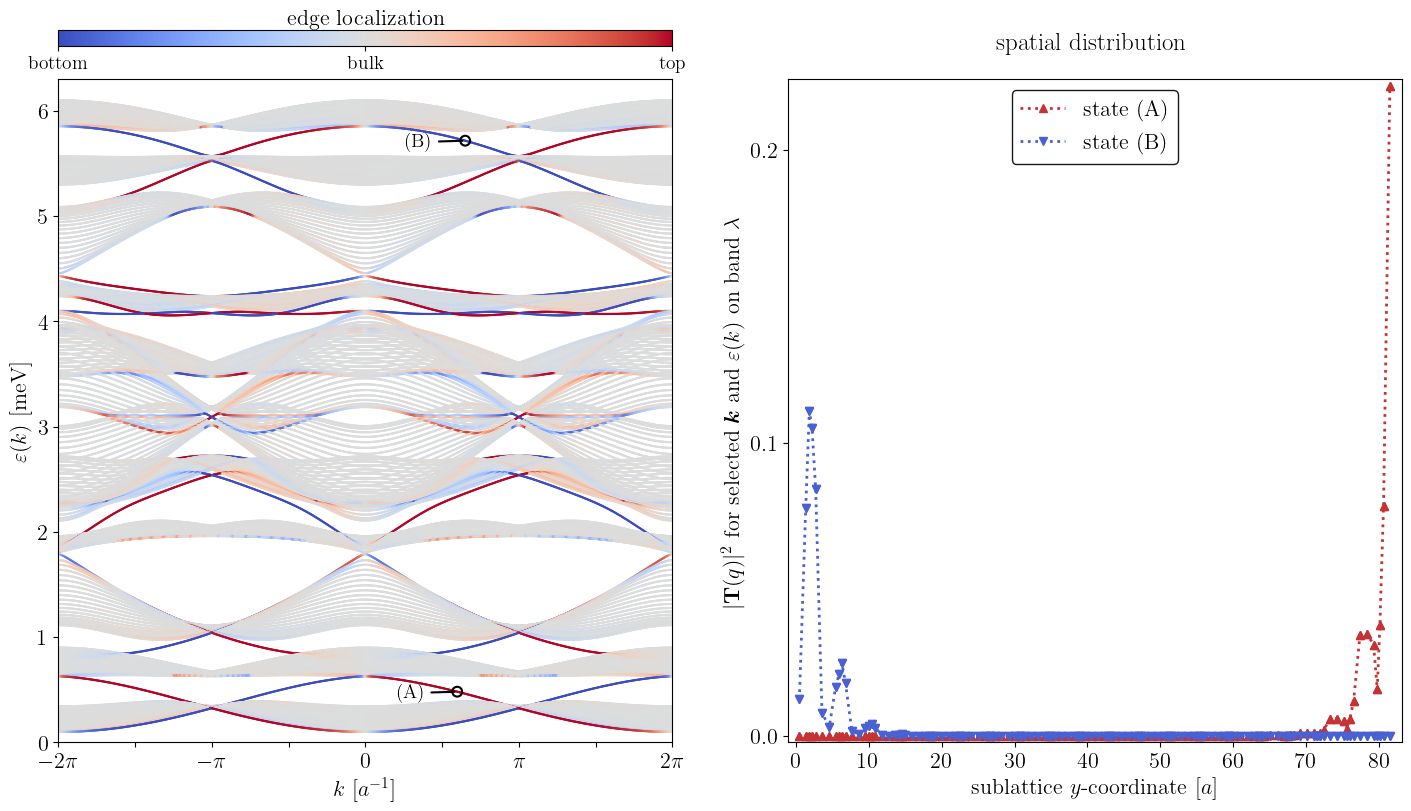

In [5]:
slab1 = Slab(zigzag_zigzag, 'truncated_trihexagonal') # zorder depending on amp to highlight edge modes better?

state_A1 = [0.3, 0.5, '(A)', 3, 185]
state_B1 = [0.325, 5.7, '(B)', 3, 185]

fig1_bs = slab1.slab_bandplot(n_unitcells = width1, k_space = 'full', states = [state_A1, state_B1])

slab1.save_plot(fig1_bs, filename = 'truncated_trihexagonal_zigzag_zigzag_bs', format= '.png', overwrite = True)

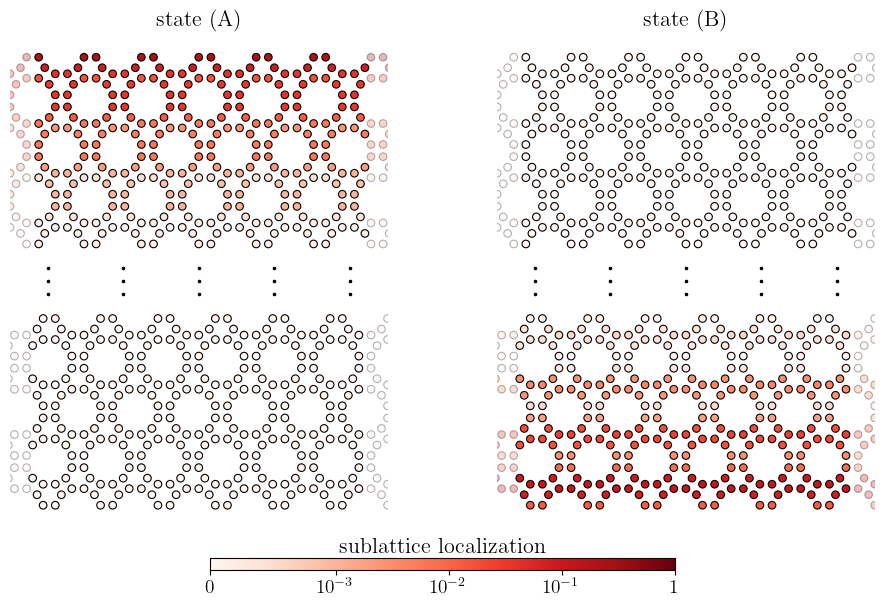

In [13]:
fig1_lat = slab1.slab_latticeplot(n_unitcells = width1, states = [state_A1, state_B1], reps = 10, gap_dot_scale = (180, 20), edge_layers = 4)

slab1.save_plot(fig1_lat, filename = 'truncated_trihexagonal_zigzag_zigzag_lat', format= '.png', overwrite = True)

In [14]:
width2 = 20
armchair_armchair = build_armchair_armchair(width2)

Setup file saved to: c:\Users\Pascal\Desktop\magnon_code\archimedean\configs_slab\truncated_trihexagonal_armchair_armchair.csv


In [15]:
armchair_armchair, _, _ = Initialize.from_csv('configs_slab/truncated_trihexagonal_armchair_armchair.csv')

armchair_armchair.HP_trafo(symbolic=True) ;

In [16]:
armchair_armchair.update_parameters({'Dz1': -0.3, 'Dz2': -0.3, 'Dz3': 0}, 1e-1)

Updated parameters and now using 0.1 as chemical potential.


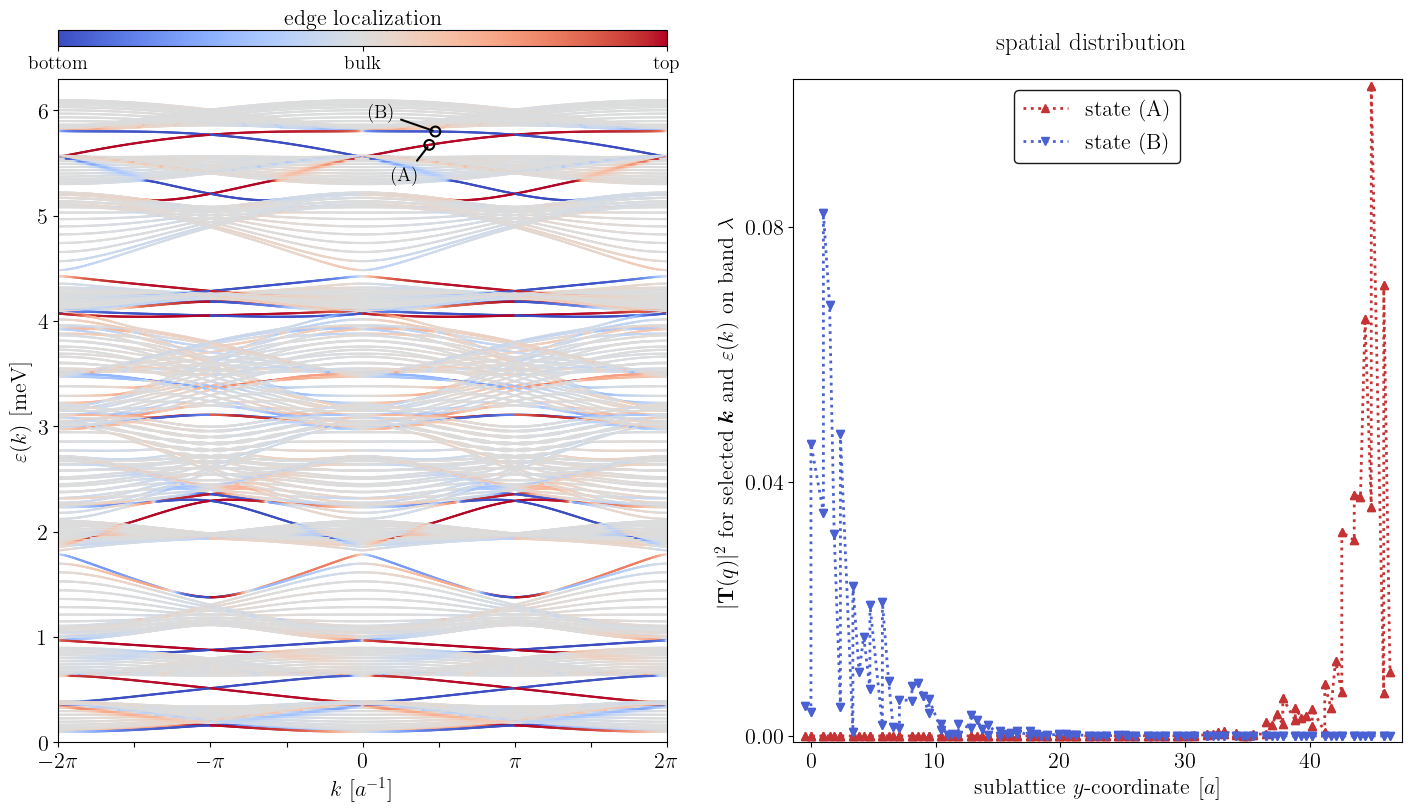

In [17]:
slab2 = Slab(armchair_armchair, 'truncated_trihexagonal')

state_A2 = [0.22, 5.7, '(A)', 6, -105]
state_B2 = [0.24, 5.75, '(B)', 5, 135]

fig2_bs = slab2.slab_bandplot(n_unitcells = width2, k_space = 'full', states = [state_A2, state_B2])

slab2.save_plot(fig2_bs, filename = 'truncated_trihexagonal_armchair_armchair_bs', format= '.png', overwrite = True)

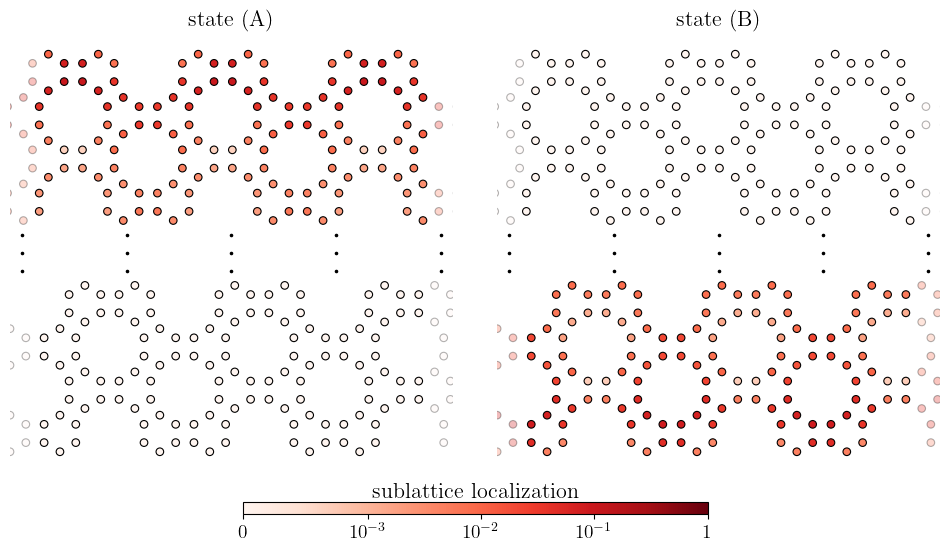

In [18]:
fig2_lat = slab2.slab_latticeplot(n_unitcells = width2, states = [state_A2, state_B2], reps = 6, gap_dot_scale = (180, 10), edge_layers = 4)

slab2.save_plot(fig2_lat, filename = 'truncated_trihexagonal_armchair_armchair_lat', format= '.png', overwrite = True)